<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Compare Stellar Parameter Coverage Across ESO Catalogues**

The goal of this notebook is to compare the stellar parameter space covered by the `AMBRE` and `GAIAESO` collections using only the catalogue TAP service - `query_tap()` - and the high-level `query_catalog()` interface.

The workflow has three main steps:

- discover the relevant catalogue tables in the `AMBRE` and `GAIAESO` collections
- identify the effective-temperature and gravity columns using their UCDs rather than hard-coded names
- retrieve only those columns and compare the distributions in `T_eff` versus `log g`

---

**Authors**: Emanuele Paolo Farina & Ashley Thomas Barnes

<hr style="border:2px solid #0281c9"> </hr>

# **Importing and basic usage of astroquery.eso**

In [1]:
import astroquery # import astroquery
print(f"astroquery version: {astroquery.__version__}") # check the version of astroquery

astroquery version: 0.4.12.dev505+gf2a77a615.d20260427


In [2]:
from astroquery.eso import Eso # import the ESO module from astroquery

import matplotlib.pyplot as plt # plotting
import numpy as np # numerical tools
from pathlib import Path # filesystem paths

In [3]:
eso = Eso() # create an instance of the ESO class

# **Discover the catalogue tables to compare**

The catalogue TAP metadata tables let us discover which published tables belong to the `AMBRE` and `GAIAESO` collections.

In [4]:
collections = ['AMBRE', 'GAIAESO']

query = """
        SELECT collection, title, version, table_name, rel_descr_url
        FROM TAP_SCHEMA.tables
        WHERE collection IN {}
        ORDER BY collection, table_name
        """.format(tuple(collections))

catalogue_tables = eso.query_tap(query, tap_endpoint="tap_cat")
catalogue_tables

collection,title,version,table_name,rel_descr_url
object,object,int32,object,object
AMBRE,Atmospheric Parameters and Chemical Abundances from Stellar Spectra - HARPS,1,AMBRE_HARPS_V1,http://www.eso.org/rm/api/v1/public/releaseDescriptions/180
AMBRE,Atmospheric Parameters and Chemical Abundances from Stellar Spectra - UVES,1,AMBRE_UVES_V1,http://www.eso.org/rm/api/v1/public/releaseDescriptions/178
AMBRE,Atmospheric Parameters and Chemical Abundances from Stellar Spectra,1,AMBRE_V1,http://www.eso.org/rm/api/v1/public/releaseDescriptions/7
GAIAESO,GAIAESO catalogue of radial velocities,1,GES_2021_VRAD,http://www.eso.org/rm/api/v1/public/releaseDescriptions/186
GAIAESO,Gaia-ESO spectroscopic survey,3,GES_DR5,http://www.eso.org/rm/api/v1/public/releaseDescriptions/191
GAIAESO,Gaia-ESO spectroscopic survey,4,GES_DR5_1_V1,http://www.eso.org/rm/api/v1/public/releaseDescriptions/210
GAIAESO,Gaia-ESO spectroscopic survey,2,GES_iDR4_PIII2016_Catalogue_v3_fits_V2,http://www.eso.org/rm/api/v1/public/releaseDescriptions/91


This metadata table provides the catalogue table names we will query, along with release-documentation links that can be useful for interpreting the products.

# **Identify the physical-parameter columns via UCDs**

Column names differ across catalogues, so rather than assuming names like `LOG_G` or `LOGG`, we search `TAP_SCHEMA.columns` for the relevant UCDs:

- `phys.temperature.effective` for effective temperature
- `phys.gravity` for surface gravity

In [5]:
ucds = ["phys.temperature.effective", "phys.gravity"]

query = """
    SELECT t.collection, c.table_name, c.column_name, c.ucd
    FROM TAP_SCHEMA.tables AS t
    JOIN TAP_SCHEMA.columns AS c ON t.table_name = c.table_name
    WHERE t.collection IN {}
    AND c.ucd IN {}
    ORDER BY collection
    """.format(tuple(collections), tuple(ucds))

parameter_columns = eso.query_tap(query, tap_endpoint="tap_cat")
parameter_columns

collection,table_name,column_name,ucd
object,object,object,object
AMBRE,AMBRE_V1,LOG_G,phys.gravity
AMBRE,AMBRE_UVES_V1,TEFF,phys.temperature.effective
AMBRE,AMBRE_UVES_V1,LOG_G,phys.gravity
AMBRE,AMBRE_HARPS_V1,TEFF,phys.temperature.effective
AMBRE,AMBRE_V1,TEFF,phys.temperature.effective
AMBRE,AMBRE_HARPS_V1,LOG_G,phys.gravity
GAIAESO,GES_iDR4_PIII2016_Catalogue_v3_fits_V2,TEFF,phys.temperature.effective
GAIAESO,GES_DR5_1_V1,LOGG,phys.gravity
GAIAESO,GES_DR5_1_V1,TEFF,phys.temperature.effective


Map table to dictionary. 

In [6]:
column_map = {}

for row in parameter_columns:
    table_name = str(row['table_name']).removeprefix('safcat.')
    entry = column_map.setdefault(
        table_name,
        {'collection': str(row['collection']), 'teff': None, 'logg': None},
    )

    if row['ucd'] == 'phys.temperature.effective':
        entry['teff'] = str(row['column_name'])
    elif row['ucd'] == 'phys.gravity':
        entry['logg'] = str(row['column_name'])

column_map = {
    table_name: cols
    for table_name, cols in column_map.items()
    if cols['teff'] is not None and cols['logg'] is not None
}

column_map

{'AMBRE_V1': {'collection': 'AMBRE', 'teff': 'TEFF', 'logg': 'LOG_G'},
 'AMBRE_UVES_V1': {'collection': 'AMBRE', 'teff': 'TEFF', 'logg': 'LOG_G'},
 'AMBRE_HARPS_V1': {'collection': 'AMBRE', 'teff': 'TEFF', 'logg': 'LOG_G'},
 'GES_iDR4_PIII2016_Catalogue_v3_fits_V2': {'collection': 'GAIAESO',
  'teff': 'TEFF',
  'logg': 'LOGG'},
 'GES_DR5_1_V1': {'collection': 'GAIAESO', 'teff': 'TEFF', 'logg': 'LOGG'},
 'GES_DR5': {'collection': 'GAIAESO', 'teff': 'TEFF', 'logg': 'LOGG'}}

# **Retrieve only the columns needed for the comparison**

To keep the workflow light, we use `query_catalog()` to retrieve just the effective-temperature and gravity columns from each table. The exact column names come from the metadata query above.

You can increase `ROW_LIMIT` or set it to `None` if you want to sample a larger fraction of the catalogues.

In [7]:
eso.ROW_LIMIT = 50000 # increase or set to None for larger comparisons

catalogue_data = {}
for table_name, cols in column_map.items():
    catalogue_data[table_name] = eso.query_catalog(
                                        catalog=table_name,
                                        columns=[cols['teff'], cols['logg']]
                                        )

list(catalogue_data)

['AMBRE_V1',
 'AMBRE_UVES_V1',
 'AMBRE_HARPS_V1',
 'GES_iDR4_PIII2016_Catalogue_v3_fits_V2',
 'GES_DR5_1_V1',
 'GES_DR5']

# **Compare the coverage in effective temperature and gravity**

We now recreate the main comparison figure as a panel of hexbin plots. This gives a compact view of the parts of stellar parameter space sampled by each catalogue table.

**Function:** `get_clean_parameter_arrays` removes rows with missing values in either parameter, which would otherwise cause the hexbin plot to fail.

In [8]:
def get_clean_parameter_arrays(table, teff_column, logg_column):
    """Return unmasked temperature and gravity arrays for plotting."""
    teff = np.ma.asarray(table[teff_column])
    logg = np.ma.asarray(table[logg_column])

    valid = ~(
        np.ma.getmaskarray(teff)
        | np.ma.getmaskarray(logg)
        | ~np.isfinite(np.asarray(teff.filled(np.nan)))
        | ~np.isfinite(np.asarray(logg.filled(np.nan)))
    )

    return np.asarray(teff[valid]), np.asarray(logg[valid])

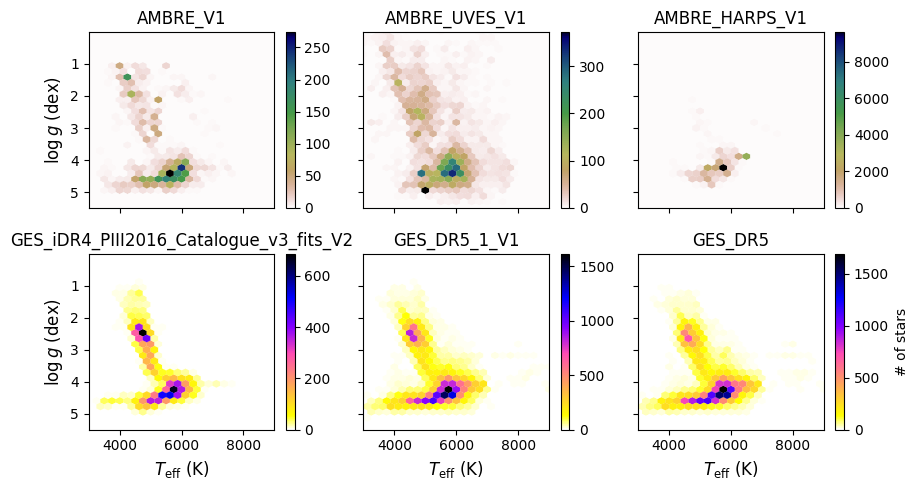

In [9]:
Path('figures').mkdir(exist_ok=True)

table_names = list(column_map)
cmaps = {
    'AMBRE': 'gist_earth_r',
    'GAIAESO': 'gnuplot2_r',
}

fig, axes = plt.subplots(
    ncols=3,
    nrows=2,
    sharex=True,
    sharey=True,
    figsize=(9, 5),
)

axes = np.array(axes).reshape(-1) # flatten axes array for easy indexing

if len(table_names) == 1:
    axes = [axes]

for ax, table_name in zip(axes, table_names):
    cols = column_map[table_name]
    teff, logg = get_clean_parameter_arrays(catalogue_data[table_name], cols['teff'], cols['logg'])
    cmap = cmaps.get(cols['collection'], 'viridis')

    ax.set_xlim(3000, 9000)  # Range for T_eff (temperature)
    ax.set_ylim(5.49, 0.01)  # Range for log g (surface gravity)

    hb = ax.hexbin(
        teff,
        logg,
        cmap=cmap,
        gridsize=30,
        extent=(2500, 10000, 0, 6),
        linewidths=0.1,
    )

    ax.set_title(table_name)
    ax.set_xlim(3000, 9000)
    ax.set_ylim(5.49, 0.01)
    cbar = plt.colorbar(hb, ax=ax)

    if ax == axes[-1]:  # only add colorbar label to the last subplot
        cbar.set_label('# of stars')

for i in [3,4,5]:
    axes[i].set_xlabel(r'$T_{\mathrm{eff}}$ (K)', size='large')
for i in [0,3]:
    axes[i].set_ylabel(r'$\log g$ (dex)', size='large')

fig.tight_layout()
fig.savefig('figures/ambre_vs_gaiaeso.png', bbox_inches='tight')

## **Inspect one catalogue in log-scaled density**

A second view uses logarithmic bin counts to show lower-density regions more clearly. 

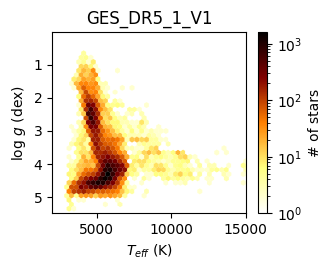

In [14]:
gaiaeso_table = "GES_DR5_1_V1"

gaiaeso_cols = column_map[gaiaeso_table]
teff, logg = get_clean_parameter_arrays(
    catalogue_data[gaiaeso_table],
    gaiaeso_cols['teff'],
    gaiaeso_cols['logg'],
)

fig, ax = plt.subplots(figsize=(3.4, 2.8))
hb = ax.hexbin(
    teff,
    logg,
    cmap='afmhot_r',
    gridsize=40,
    extent=(2000, 15000, 0, 6),
    linewidths=0.1,
    bins='log',
)

ax.set_title(gaiaeso_table)
ax.set_xlim(2000, 15000)
ax.set_ylim(5.49, 0.01)
ax.set_xlabel(r'$T_{eff}$ (K)')
ax.set_ylabel(r'$\log\,g$ (dex)')

cbar = plt.colorbar(hb, ax=ax)
cbar.set_label('# of stars')

fig.tight_layout()
fig.savefig('figures/gaiaeso_log_density.png', bbox_inches='tight')

<hr style="border:2px solid #0281c9"> </hr>